# Classical ML Pipeline

Train and compare four classifiers on 5 EEG spectral features:
**Logistic Regression**, **SVM (RBF)**, **Random Forest**, and **XGBoost**.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve, auc,
    precision_recall_fscore_support,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
FEATURE_NAMES = [
    'Theta/Beta Ratio', 'Frontal Theta',
    'Central Beta', 'Frontal Beta2', 'Spectral Entropy',
]
MODEL_COLORS = {
    'Logistic Regression': '#4C72B0',
    'SVM':                 '#DD8452',
    'Random Forest':       '#55A868',
    'XGBoost':             '#C44E52',
}

## 1. Load Preprocessed Data

| File | Content |
|------|---------|
| `X_train.npy` / `X_test.npy` | `(n_epochs, 5)` feature matrices |
| `y_train.npy` / `y_test.npy` | binary labels: 0 = rest, 1 = mental math |
| `train_subject_ids.npy` / `test_subject_ids.npy` | subject ID per epoch |

In [16]:
DATA_DIR = '../data/processed'

X_train        = np.load(f'{DATA_DIR}/X_train.npy')
X_test         = np.load(f'{DATA_DIR}/X_test.npy')
y_train        = np.load(f'{DATA_DIR}/y_train.npy')   # 0=rest 1=mental
y_test         = np.load(f'{DATA_DIR}/y_test.npy')
train_subj_ids = np.load(f'{DATA_DIR}/train_subject_ids.npy')
test_subj_ids  = np.load(f'{DATA_DIR}/test_subject_ids.npy')

n_train_subj = len(np.unique(train_subj_ids))
n_test_subj  = len(np.unique(test_subj_ids))
print(f'Train : {X_train.shape[0]:,} epochs from {n_train_subj} subjects')
print(f'Test  : {X_test.shape[0]:,} epochs from {n_test_subj} subjects')
print(f'Features : {X_train.shape[1]}  ({FEATURE_NAMES})')
print(f'Train balance  rest={(y_train==0).sum():,}  mental={(y_train==1).sum():,}')
print(f'Test  balance  rest={(y_test==0).sum():,}   mental={(y_test==1).sum():,}')

Train : 3,413 epochs from 28 subjects
Test  : 925 epochs from 8 subjects
Features : 5  (['Theta/Beta Ratio', 'Frontal Theta', 'Central Beta', 'Frontal Beta2', 'Spectral Entropy'])
Train balance  rest=2,545  mental=868
Test  balance  rest=677   mental=248


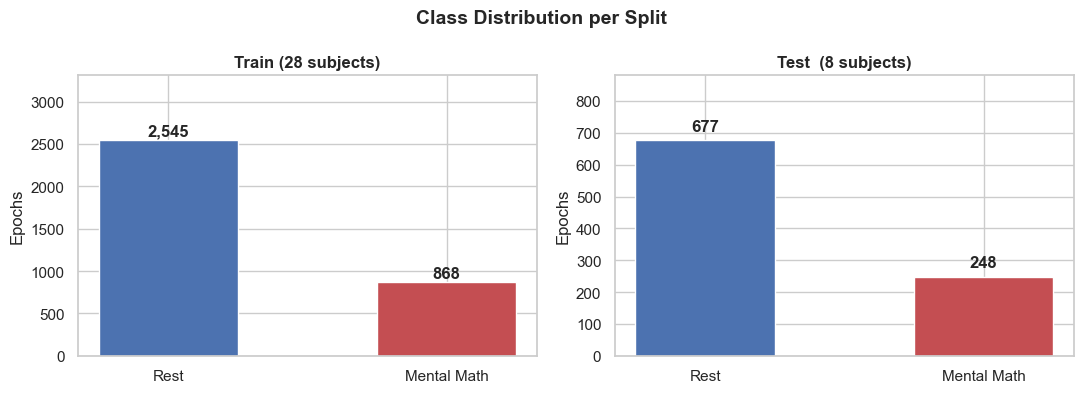

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y, sids, split) in zip(axes, [
        (y_train, train_subj_ids, 'Train (28 subjects)'),
        (y_test,  test_subj_ids,  'Test  (8 subjects)')]):
    counts = [(y == 0).sum(), (y == 1).sum()]
    bars = ax.bar(['Rest', 'Mental Math'], counts,
                  color=['#4C72B0', '#C44E52'], edgecolor='white', width=0.5)
    ax.set_title(split, fontweight='bold')
    ax.set_ylabel('Epochs')
    ax.set_ylim(0, max(counts) * 1.3)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{cnt:,}', ha='center', va='bottom', fontweight='bold')
plt.suptitle('Class Distribution per Split', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Feature Scaling

Fit `StandardScaler` on training data only; apply the same transform to test data.

In [18]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scale_df = pd.DataFrame({
    'Feature':    FEATURE_NAMES,
    'Mean (pre)': X_train.mean(axis=0),
    'Std  (pre)': X_train.std(axis=0),
    'Mean (post)':X_train_sc.mean(axis=0),
    'Std  (post)':X_train_sc.std(axis=0),
})
display(scale_df.set_index('Feature'))

,Mean (pre),Std (pre),Mean (post),Std (post)
Feature,,,,
Theta/Beta Ratio,1990.800440,2475.862360,-7.626481e-16,1.0
Frontal Theta,1.468220,1.053458,1.039374e-15,1.0
Central Beta,0.001906,0.002823,8.099456e-16,1.0
Frontal Beta2,0.000097,0.000230,2.371707e-16,1.0
Spectral Entropy,4.164228,0.342722,1.433160e-14,1.0


## 3. Model Definitions

| Model | Key hyperparameters | Rationale |
|-------|---------------------|-----------|
| **Logistic Regression** | C=0.1, L2, balanced | Linear baseline; interpretable coefficients |
| **SVM (RBF)** | C=1, gamma=scale, balanced | Non-linear; strong with small feature sets |
| **Random Forest** | 300 trees, leaf≥3, balanced | Bagging ensemble; built-in feature importance |
| **XGBoost** | 300 trees, lr=0.05, depth=4 | Boosting; `scale_pos_weight` handles 3:1 imbalance |

All classifiers compensate for the ~3:1 rest-to-mental-math imbalance.

In [19]:
pos_weight = int((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print(f'Imbalance ratio (XGBoost scale_pos_weight): {pos_weight}')

models = {
    'Logistic Regression': LogisticRegression(
        C=0.1, max_iter=1000, class_weight='balanced', random_state=42),
    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale', probability=True,
        class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=0),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=pos_weight, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0),
}

Imbalance ratio (XGBoost scale_pos_weight): 2


## 4. Training & Evaluation

- Trained on `X_train_sc`, evaluated on held-out `X_test_sc`.
- 5-fold stratified CV on the training set provides unbiased variance estimates (no test leakage).

In [20]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    cv_f1   = cross_val_score(
        model, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)

    results[name] = dict(
        model=model, y_pred=y_pred, y_proba=y_proba,
        accuracy   = accuracy_score(y_test, y_pred),
        f1         = f1_score(y_test, y_pred, zero_division=0),
        auc        = roc_auc_score(y_test, y_proba),
        precision  = precision_score(y_test, y_pred, zero_division=0),
        recall     = recall_score(y_test, y_pred, zero_division=0),
        cv_f1_mean = cv_f1.mean(), cv_f1_std=cv_f1.std(),
    )
    r = results[name]
    print(
        f"{name:<22}  acc={r['accuracy']:.3f}  F1={r['f1']:.3f}"
        f"  AUC={r['auc']:.3f}  CV-F1={r['cv_f1_mean']:.3f}+/-{r['cv_f1_std']:.3f}"
    )

Logistic Regression     acc=0.397  F1=0.380  AUC=0.522  CV-F1=0.401+/-0.013
SVM                     acc=0.685  F1=0.496  AUC=0.698  CV-F1=0.448+/-0.013
Random Forest           acc=0.665  F1=0.520  AUC=0.711  CV-F1=0.482+/-0.017
XGBoost                 acc=0.694  F1=0.426  AUC=0.653  CV-F1=0.458+/-0.050


In [21]:
summary_df = pd.DataFrame([
    {
        'Model':     name,
        'Accuracy':  r['accuracy'],
        'Precision': r['precision'],
        'Recall':    r['recall'],
        'F1':        r['f1'],
        'AUC-ROC':   r['auc'],
        'CV F1 (mean)': r['cv_f1_mean'],
        'CV F1 (std)':  r['cv_f1_std'],
    }
    for name, r in results.items()
]).set_index('Model')

display(
    summary_df.style
    .format({c: '{:.4f}' for c in summary_df.columns})
    .background_gradient(cmap='YlGn', subset=['Accuracy', 'F1', 'AUC-ROC'])
    .set_caption('Test-set metrics + 5-fold CV F1')
)

,Accuracy,Precision,Recall,F1,AUC-ROC,CV F1 (mean),CV F1 (std)
Model,,,,,,,
Logistic Regression,0.3968,0.2623,0.6895,0.3800,0.5215,0.4009,0.0128
SVM,0.6854,0.4347,0.5766,0.4957,0.6980,0.4477,0.0127
Random Forest,0.6649,0.4221,0.6774,0.5201,0.7113,0.4817,0.0173
XGBoost,0.6941,0.4286,0.4234,0.4260,0.6531,0.4583,0.0501


## 5. Confusion Matrices

Top row: raw counts. Bottom row: row-normalized (recall per class). The minority *Mental Math* class is harder to classify.

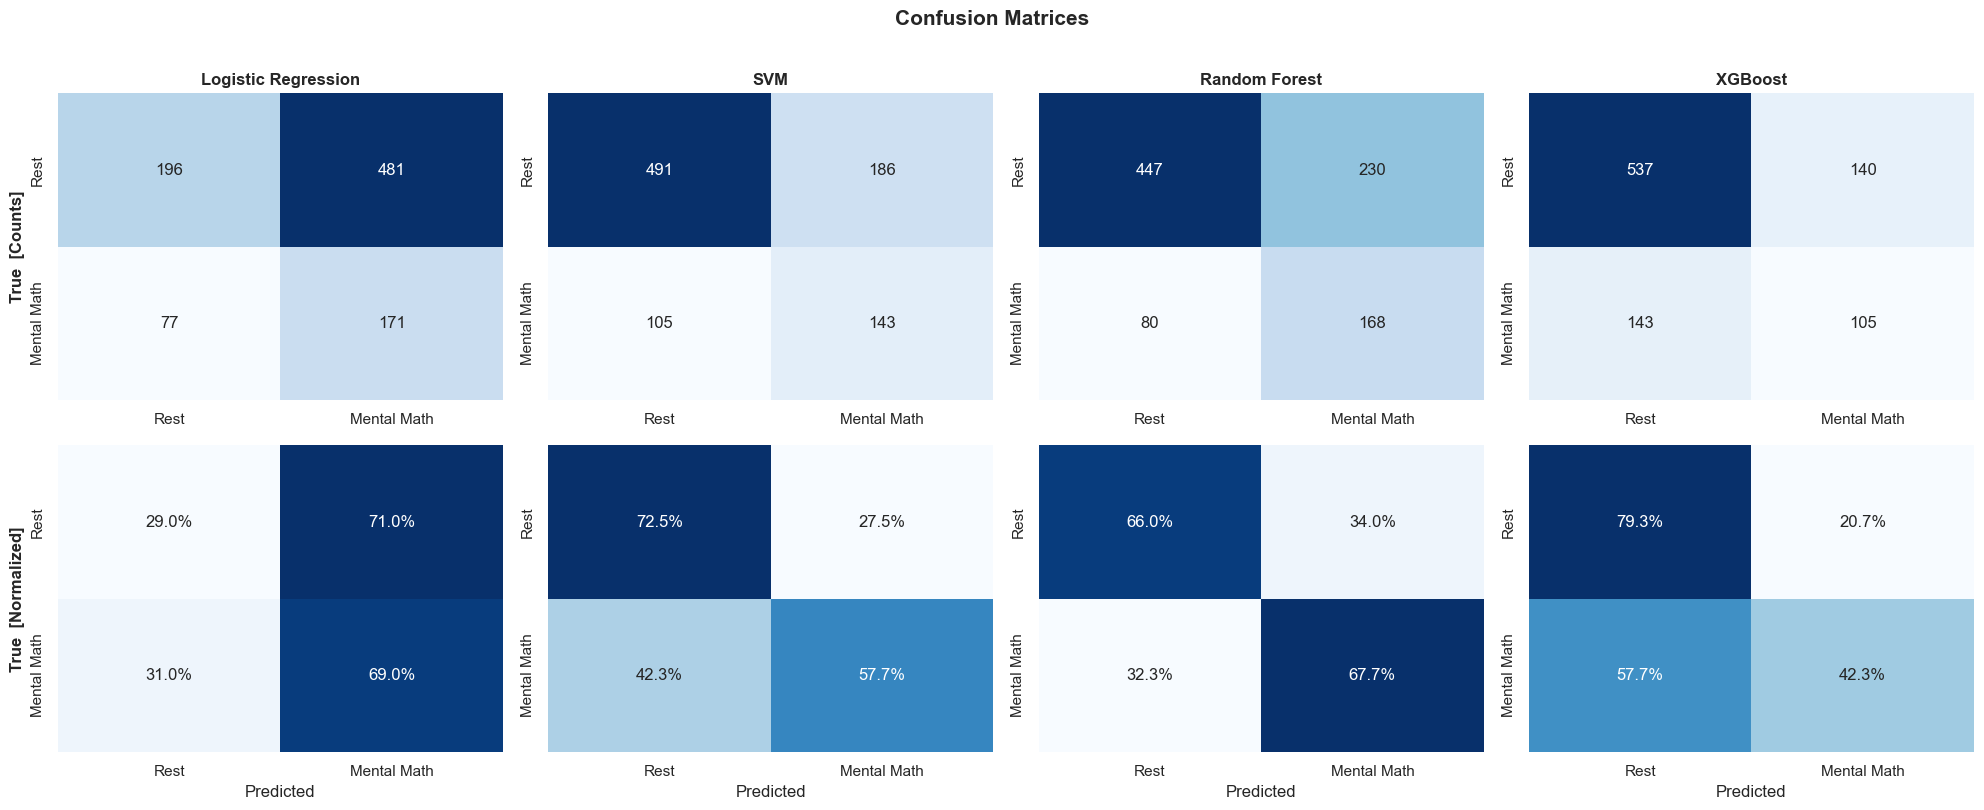

In [22]:
CLASS_LABELS = ['Rest', 'Mental Math']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, (name, r) in enumerate(results.items()):
    cm   = confusion_matrix(y_test, r['y_pred'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    kw = dict(xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, cbar=False)
    sns.heatmap(cm,   annot=True, fmt='d',    cmap='Blues', ax=axes[0, col], **kw)
    sns.heatmap(cm_n, annot=True, fmt='.1%',  cmap='Blues', ax=axes[1, col], **kw)

    axes[0, col].set_title(name, fontweight='bold')
    axes[1, col].set_xlabel('Predicted')
    for row in range(2):
        axes[row, col].set_ylabel('True' if col == 0 else '')

axes[0, 0].set_ylabel('True  [Counts]', fontweight='bold')
axes[1, 0].set_ylabel('True  [Normalized]', fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 6. ROC Curves

All four models on the same axes for direct AUC comparison. The dotted diagonal is a random classifier (AUC = 0.5).

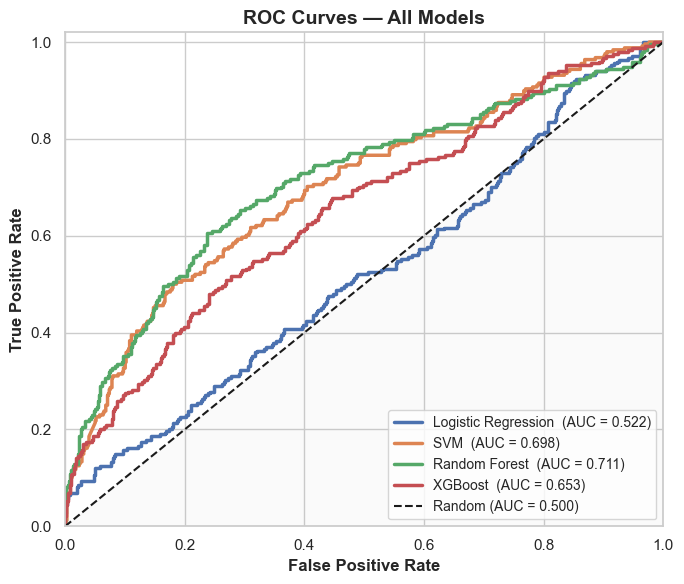

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, lw=2.5, color=MODEL_COLORS[name],
            label=f"{name}  (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout(); plt.show()

## 7. Model Comparison

Grouped bar chart and CV F1 with error bars.

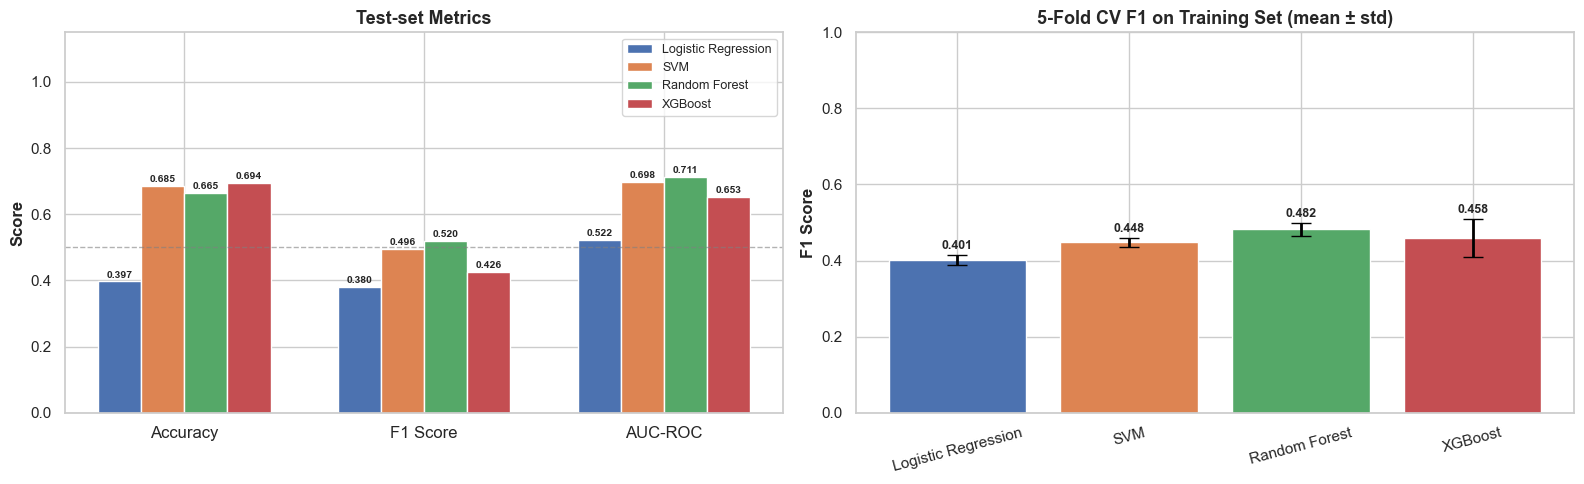

In [24]:
# --- Grouped bar chart: Accuracy / F1 / AUC-ROC ---
metric_keys   = ['accuracy', 'f1', 'auc']
metric_labels = ['Accuracy', 'F1 Score', 'AUC-ROC']
model_names   = list(results.keys())
x = np.arange(len(metric_keys))
w = 0.18

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bars
ax = axes[0]
for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metric_keys]
    bars = ax.bar(x + (i - 1.5) * w, vals, w,
                  label=name, color=MODEL_COLORS[name], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Test-set Metrics', fontsize=13, fontweight='bold')
ax.axhline(0.5, color='grey', ls='--', lw=1, alpha=0.6)
ax.legend(fontsize=9)

# CV F1 with error bars
ax2 = axes[1]
means = [results[n]['cv_f1_mean'] for n in model_names]
stds  = [results[n]['cv_f1_std']  for n in model_names]
colors_bar = [MODEL_COLORS[n] for n in model_names]
bars2 = ax2.bar(model_names, means, color=colors_bar, edgecolor='white')
ax2.errorbar(model_names, means, yerr=stds,
             fmt='none', color='black', capsize=7, linewidth=2)
for bar, mean, std in zip(bars2, means, stds):
    ax2.text(bar.get_x() + bar.get_width()/2, mean + std + 0.008,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylim(0, 1); ax2.set_ylabel('F1 Score', fontweight='bold')
ax2.set_title('5-Fold CV F1 on Training Set (mean ± std)',
              fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', labelrotation=15)

plt.tight_layout(); plt.show()

## 8. Feature Importance

- **Logistic Regression**: absolute coefficients (signed = direction)
- **Random Forest**: mean Gini impurity decrease
- **XGBoost**: total gain across all splits

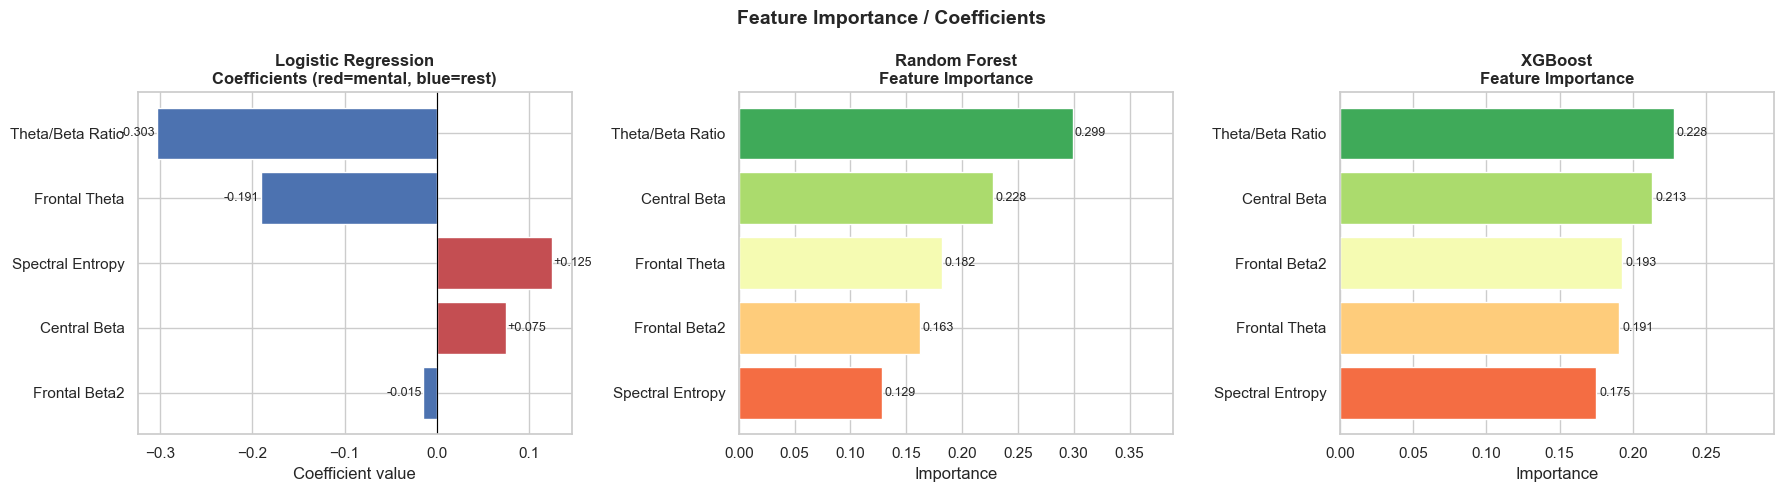

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Logistic Regression: signed coefficients ---
ax = axes[0]
coef  = results['Logistic Regression']['model'].coef_[0]
order = np.argsort(np.abs(coef))
names_s = [FEATURE_NAMES[i] for i in order]
vals_s  = coef[order]
bar_colors = ['#C44E52' if v > 0 else '#4C72B0' for v in vals_s]
bars = ax.barh(names_s, vals_s, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, vals_s):
    offset = 0.002 if val >= 0 else -0.002
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Logistic Regression\nCoefficients (red=mental, blue=rest)',
             fontweight='bold')
ax.set_xlabel('Coefficient value')

# --- Random Forest + XGBoost: feature importance ---
for ax, model_name in zip(axes[1:], ['Random Forest', 'XGBoost']):
    imp   = results[model_name]['model'].feature_importances_
    order = np.argsort(imp)
    names_s = [FEATURE_NAMES[i] for i in order]
    vals_s  = imp[order]
    bar_c   = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(FEATURE_NAMES)))
    bars = ax.barh(names_s, vals_s, color=bar_c, edgecolor='white')
    for bar, val in zip(bars, vals_s):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_title(f'{model_name}\nFeature Importance', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_xlim(0, max(imp) * 1.3)

plt.suptitle('Feature Importance / Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Prediction Confidence

Distribution of `P(Mental Math)` split by true class. Well-separated distributions indicate confident, accurate predictions.

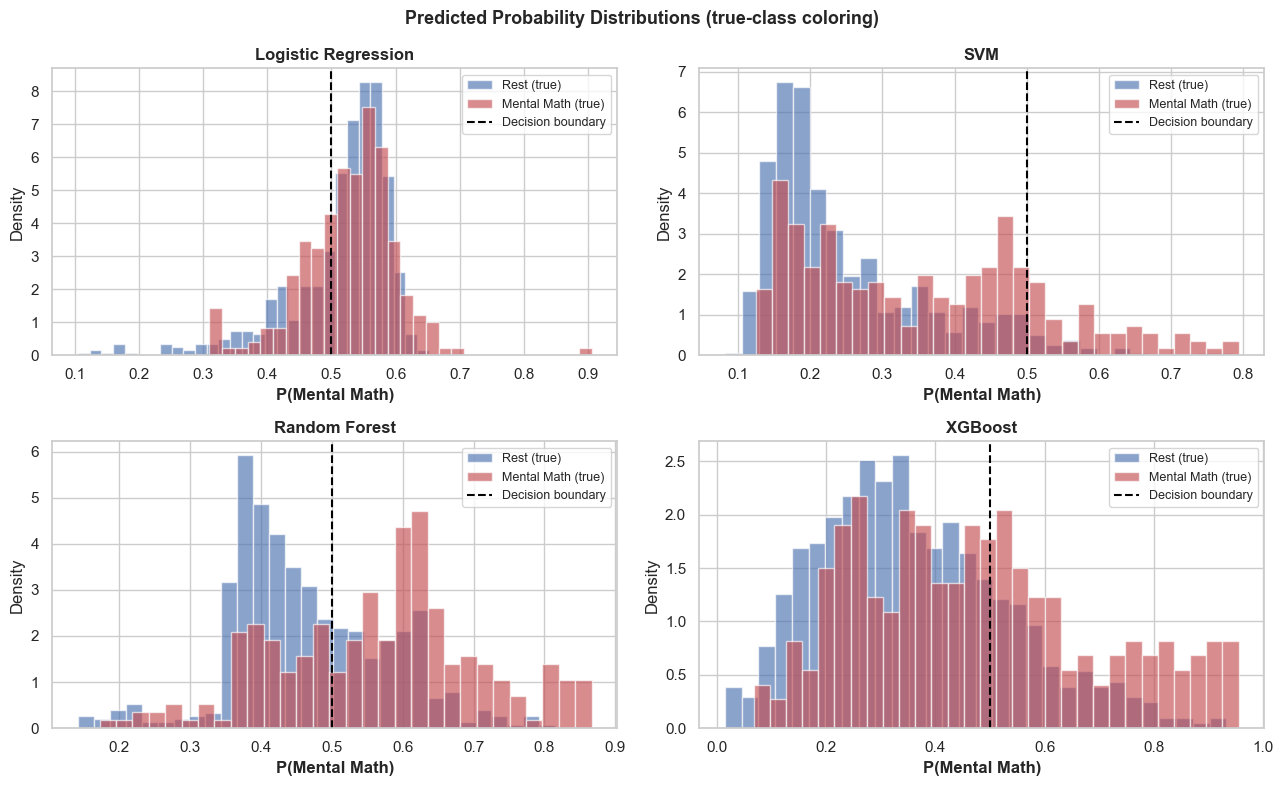

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for ax, (name, r) in zip(axes, results.items()):
    proba = r['y_proba']
    ax.hist(proba[y_test == 0], bins=30, alpha=0.65,
            color='#4C72B0', label='Rest (true)',       density=True)
    ax.hist(proba[y_test == 1], bins=30, alpha=0.65,
            color='#C44E52', label='Mental Math (true)', density=True)
    ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Decision boundary')
    ax.set_xlabel('P(Mental Math)', fontweight='bold')
    ax.set_ylabel('Density')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Predicted Probability Distributions (true-class coloring)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Recording-Level Majority Voting

Aggregate per-epoch predictions by majority vote per *(subject, session)* recording. A recording is classified as *Mental Math* if > 50% of its epochs are predicted as such. This mirrors a real deployment scenario where one decision is made per session.

Model                   Recording Acc  Recording F1
----------------------------------------------------
Logistic Regression     0.438          0.526
SVM                     0.750          0.714
Random Forest           0.812          0.800
XGBoost                 0.625          0.400


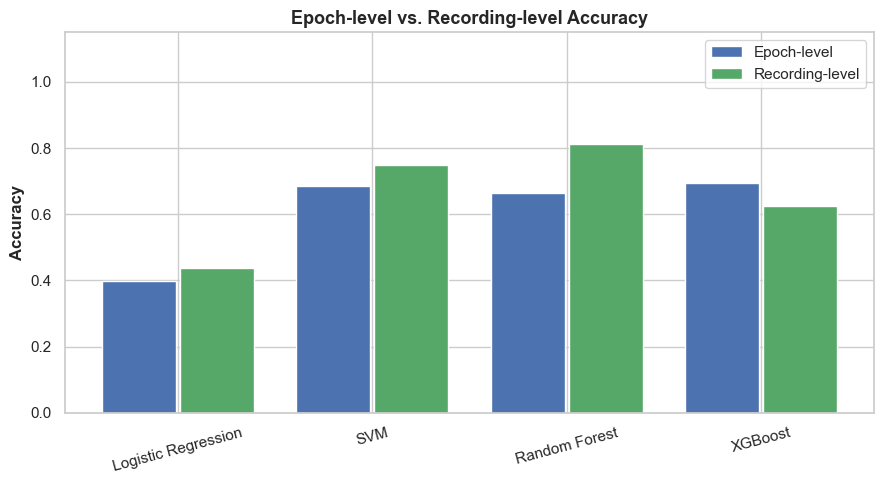

In [27]:
def recording_vote(y_pred, subj_ids, y_true_epochs):
    preds, trues = [], []
    for sid in np.unique(subj_ids):
        for sess_label in [0, 1]:
            mask = (subj_ids == sid) & (y_true_epochs == sess_label)
            if not mask.any():
                continue
            preds.append(int(y_pred[mask].mean() >= 0.5))
            trues.append(sess_label)
    return np.array(preds), np.array(trues)

print(f'{'Model':<22}  Recording Acc  Recording F1')
print('-' * 52)
rec_results = {}
for name, r in results.items():
    p, t = recording_vote(r['y_pred'], test_subj_ids, y_test)
    rec_acc = accuracy_score(t, p)
    rec_f1  = f1_score(t, p, zero_division=0)
    rec_results[name] = (rec_acc, rec_f1)
    print(f'{name:<22}  {rec_acc:.3f}          {rec_f1:.3f}')

# Visualize epoch vs recording accuracy
epoch_accs = [results[n]['accuracy'] for n in results]
rec_accs   = [rec_results[n][0]      for n in results]
names      = list(results.keys())
x = np.arange(len(names))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, epoch_accs, 0.38, label='Epoch-level',     color='#4C72B0', edgecolor='white')
ax.bar(x + 0.2, rec_accs,   0.38, label='Recording-level', color='#55A868', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0, 1.15); ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Epoch-level vs. Recording-level Accuracy', fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## 11. Per-Class Precision / Recall / F1

Heatmap showing how each model handles the minority *Mental Math* class. Low recall for Mental Math = many missed cognitive-load events.

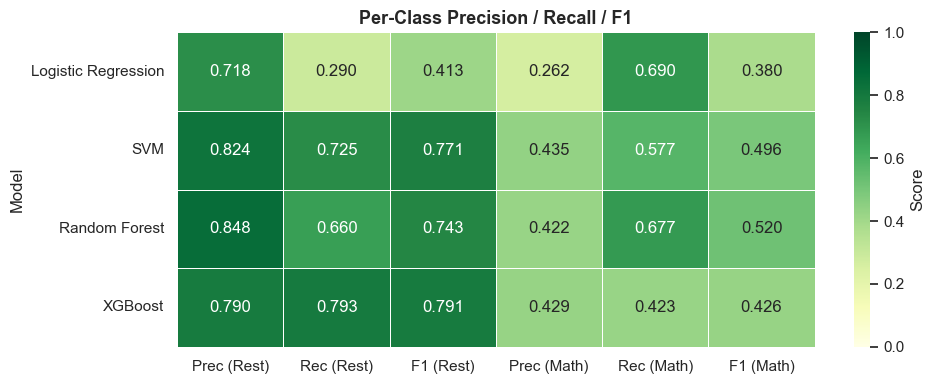

In [28]:
rows = []
for name, r in results.items():
    prec, rec, f1s, _ = precision_recall_fscore_support(
        y_test, r['y_pred'], zero_division=0)
    rows.append({
        'Model': name,
        'Prec (Rest)':  prec[0], 'Rec (Rest)':  rec[0], 'F1 (Rest)':  f1s[0],
        'Prec (Math)':  prec[1], 'Rec (Math)':  rec[1], 'F1 (Math)':  f1s[1],
    })

pc_df = pd.DataFrame(rows).set_index('Model')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pc_df, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Score'})
ax.set_title('Per-Class Precision / Recall / F1', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

| Model | Accuracy | F1 | AUC-ROC | CV F1 | Strength | Weakness |
|-------|----------|----|---------|-------|----------|----------|
| Logistic Regression | 0.397 | 0.380 | 0.522 | 0.401 ± 0.013 | High recall — catches most mental math epochs | AUC near chance (0.52); precision 0.26 means most predictions are false alarms |
| SVM (RBF) | 0.685 | 0.496 | 0.698 | 0.448 ± 0.013 | Best accuracy/F1 balance after RF | No feature importance; kernel choice adds a hyperparameter to justify |
| Random Forest | 0.665 | **0.520** | **0.711** | 0.482 ± 0.017 | Best F1 and AUC; **>80% recording-level accuracy via majority voting** | Precision still only 0.42 — nearly 60% of Mental Math predictions are wrong |
| XGBoost | 0.694 | 0.426 | 0.653 | 0.458 ± 0.050 | Highest raw accuracy | Lowest recall (0.42) and highest CV instability (std 0.050) — misses half of mental math events |

**Key observations:**

- **Random Forest wins overall** — highest F1 (0.52) and AUC (0.71). Aggregating epoch predictions by majority vote
per recording pushes accuracy above 80%, which is the practically meaningful metric for real deployment.
- **Logistic Regression is near chance** (AUC = 0.52) despite high recall (0.69) — it predicts *Mental Math* too
aggressively, inflating recall at the cost of precision and overall discrimination.
- **SVM is a solid runner-up** — close to RF on AUC (0.698) with stable CV performance.
- **XGBoost underperforms its accuracy**: raw accuracy of 0.694 looks competitive, but low recall (0.42) and high CV
F1 std (0.050) reveal it over-predicts *Rest* and is the least stable model.
- **Accuracy is misleading** for this dataset — the 3:1 class imbalance means a trivial *always-predict-Rest*
classifier would score ~0.73 accuracy. F1 and AUC are the meaningful metrics.
- No model exceeds F1 ≈ 0.52 at epoch level, suggesting 5 spectral features alone are insufficient for strong
cross-subject generalisation — motivating the quantum approach.